# 02. Прогон стратегий — D4v2 FAQ Architecture Experiment

**Цель**: прогнать N запросов × 5 стратегий (N определяется eval set).

**Шаги**:
1. Загрузка конфигурации, chunks, eval set
2. Инициализация стратегий и LLM runner
3. Прогон через orchestrator с checkpoint
4. Базовая статистика результатов

**Артефакты**: `outputs/raw_results.jsonl`

In [11]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../..')

import os
from pathlib import Path

from d4.config import load_config

# Загрузка и валидация конфигурации
config = load_config('../configs/experiment.yaml')

print(f'Эксперимент: {config.experiment.name}')
print(f'LLM: {config.llm.model}')
print(f'Embedding: {config.embedding.model}')
print(f'Seed: {config.experiment.seed}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Эксперимент: D4v2_faq_architecture_experiment
LLM: Qwen/Qwen3-Next-80B-A3B-Instruct
Embedding: BAAI/bge-m3
Seed: 42


## 1. Загрузка данных

In [12]:
from d4.pipeline.chunker import load_chunks
from d4.data_gen.query_generator import load_eval_set

# KB chunks
chunks = load_chunks('../data/kb/chunks.json')
print(f'Загружено chunks: {len(chunks)}')
print(f'Общий размер: {sum(c.token_count for c in chunks)} токенов')

# Eval set
# ВАЖНО: использовать eval_set.yaml (финальный) если есть, иначе eval_set_raw.yaml
eval_path = Path('../data/eval_set.yaml')
if not eval_path.exists():
    eval_path = Path('../data/eval_set_raw.yaml')
    print(f'WARN: используется raw eval set ({eval_path})')

samples = load_eval_set(eval_path)
print(f'Загружено запросов: {len(samples)}')

Загружено chunks: 36
Общий размер: 6196 токенов
Загружено запросов: 90


## 1.5 Очистка старых результатов (при полном перезапуске)

**ВНИМАНИЕ**: следующая ячейка удалит все предыдущие результаты.
Запускайте только при полном перезапуске эксперимента.

In [13]:
CLEAN_START = True  # Установить False для дозагрузки (resume)

if CLEAN_START:
    import shutil
    outputs_dir = Path('../outputs')
    old_files = list(outputs_dir.glob('*'))
    if old_files:
        for f in old_files:
            if f.is_file() and f.suffix in ('.jsonl', '.json', '.csv'):
                f.unlink()
                print(f'  удалён: {f.name}')
        print(f'Очищено {len(old_files)} файлов в outputs/')
    else:
        print('outputs/ пуст — чистый запуск')

  удалён: metrics_summary.csv
  удалён: pairwise_tests.csv
  удалён: raw_results.jsonl
  удалён: judge_scores.json
Очищено 8 файлов в outputs/


## 2. Инициализация стратегий и LLM runner

In [14]:
from d4.pipeline.factory import build_strategies, build_llm_runner, precompute_embeddings

# API ключ из переменной окружения
api_key = os.environ.get('OPENROUTER_API_KEY', '')
assert api_key, 'Установите OPENROUTER_API_KEY'

# Инициализация стратегий и LLM runner из единого конфига
strategies = build_strategies(config, include_baseline=True)
llm_runner = build_llm_runner(config, api_key)

print('Стратегии инициализированы:')
for s in strategies:
    print(f'  {s.strategy_id}: {s.name} (uses_llm={s.uses_llm})')

Стратегии инициализированы:
  S1: Full Context (uses_llm=True)
  S2: Lexical Retrieval (uses_llm=True)
  S3: Vector Retrieval (uses_llm=True)
  S4: Hybrid Retrieval (uses_llm=True)
  B0: Keyword + Template (uses_llm=False)


In [15]:
# Предвычисление embeddings для S3 и S4
print('Предвычисление embeddings для vector стратегий...')
precompute_embeddings(strategies, chunks)
print('Готово.')

Предвычисление embeddings для vector стратегий...
Готово.


## 3. Прогон через orchestrator

In [16]:
from d4.pipeline.orchestrator import Orchestrator

output_path = Path('../outputs/raw_results.jsonl')

orchestrator = Orchestrator(
    strategies=strategies,
    llm_runner=llm_runner,
    chunks=chunks,
    checkpoint_every=config.rate_limit.checkpoint_every_n,
    max_workers=config.rate_limit.max_workers,
    output_path=output_path,
)

# Resume: загрузить уже обработанные (при CLEAN_START=True будет пусто)
existing = Orchestrator.load_results(output_path)
resume_keys = Orchestrator.get_completed_keys(existing)
total_expected = len(samples) * len(strategies)
print(f'Уже обработано: {len(resume_keys)} результатов')
print(f'Осталось: {total_expected - len(resume_keys)} из {total_expected}')

Уже обработано: 0 результатов
Осталось: 450 из 450


In [17]:
# Запуск прогона (можно прервать и продолжить — checkpoint сохраняется)
results = orchestrator.run_all(
    samples=samples,
    resume_from=resume_keys,
    existing_results=existing,
)

# Объединяем с ранее загруженными
all_results = existing + results
print(f'\nИтого результатов: {len(all_results)}')

  запуск: 450 задач, 8 потоков
  checkpoint: 25/450 (2.6 req/s, ETA 161s)
  checkpoint: 50/450 (2.7 req/s, ETA 147s)
  checkpoint: 75/450 (2.9 req/s, ETA 130s)
  checkpoint: 100/450 (2.9 req/s, ETA 121s)
  checkpoint: 125/450 (2.9 req/s, ETA 112s)
  checkpoint: 150/450 (2.9 req/s, ETA 104s)
  checkpoint: 175/450 (2.9 req/s, ETA 96s)
  checkpoint: 200/450 (2.9 req/s, ETA 86s)
  checkpoint: 225/450 (2.9 req/s, ETA 77s)
  checkpoint: 250/450 (3.0 req/s, ETA 67s)
  checkpoint: 275/450 (3.0 req/s, ETA 58s)
  checkpoint: 300/450 (3.0 req/s, ETA 50s)
  checkpoint: 325/450 (3.0 req/s, ETA 41s)
  checkpoint: 350/450 (3.0 req/s, ETA 33s)
  checkpoint: 375/450 (3.1 req/s, ETA 25s)
  checkpoint: 400/450 (3.0 req/s, ETA 17s)
  checkpoint: 425/450 (3.0 req/s, ETA 8s)
  checkpoint: 450/450 (3.0 req/s, ETA 0s)
Готово: 450/450 за 151.0s

Итого результатов: 450


## 4. Базовая статистика

In [18]:
import pandas as pd
import numpy as np

# Используем in-memory результаты; fallback — файл
if 'all_results' not in dir() or not all_results:
    all_results = Orchestrator.load_results(output_path)

if not all_results:
    print('WARN: нет результатов — перезапустите cells 8-9 для генерации')
else:
    df = pd.DataFrame([
        {
            'sample_id': r.sample_id,
            'strategy': r.strategy_id.value,
            'latency_ms': r.latency_ms,
            'tokens_prompt': r.tokens_prompt,
            'tokens_completion': r.tokens_completion,
            'context_length': r.context_length,
            'answerable': r.answer.answerable,
            'has_error': r.error is not None,
        }
        for r in all_results
    ])

    print('Сводка по стратегиям:')
    summary = df.groupby('strategy').agg(
        n=('sample_id', 'count'),
        latency_p50=('latency_ms', lambda x: np.percentile(x, 50)),
        latency_p95=('latency_ms', lambda x: np.percentile(x, 95)),
        mean_prompt_tokens=('tokens_prompt', 'mean'),
        mean_context=('context_length', 'mean'),
        error_rate=('has_error', 'mean'),
    ).round(1)

    print(summary.to_string())

Сводка по стратегиям:
           n  latency_p50  latency_p95  mean_prompt_tokens  mean_context  error_rate
strategy                                                                            
B0        90          0.8          1.5                 0.0        2739.2         0.0
S1        90       4450.7       7536.8              8631.9        6196.0         0.0
S2        90       2579.5       4470.7              1399.8         703.5         0.0
S3        90       2721.8       4307.1              1894.6        1075.6         0.0
S4        90       2876.5       4308.0              1976.0        1131.5         0.0


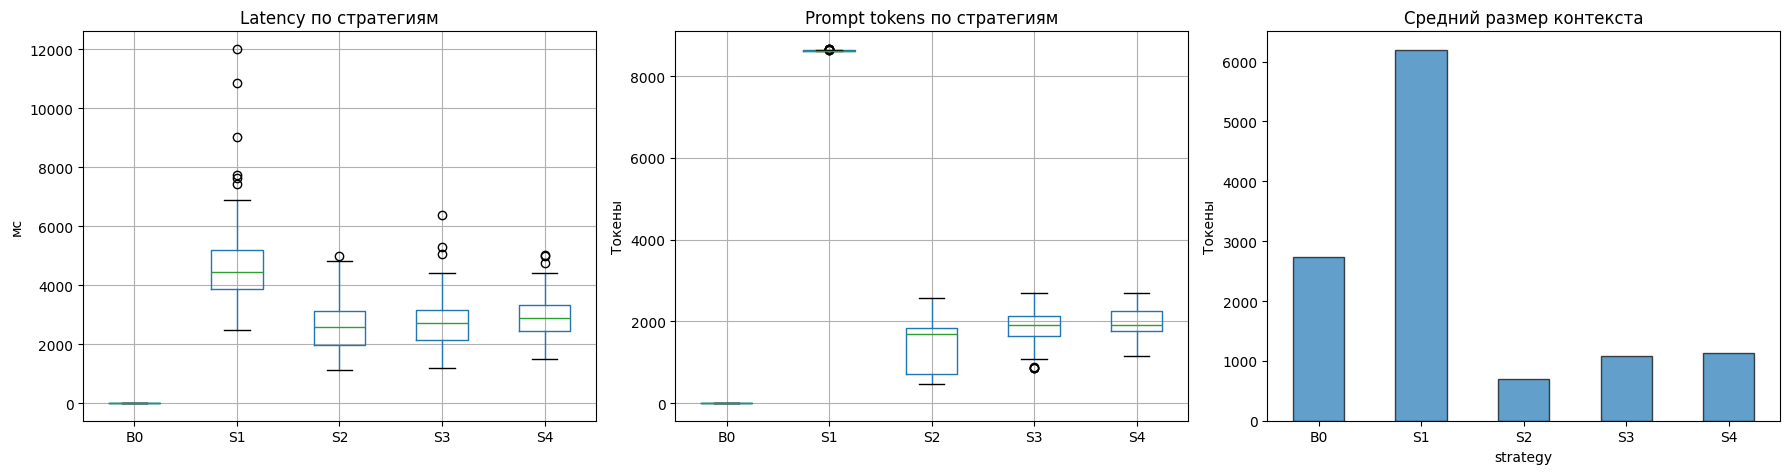

In [19]:
import matplotlib.pyplot as plt

if 'df' not in dir() or df.empty:
    print('WARN: нет данных для визуализации — перезапустите cells 8-9, затем cell 11')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Latency
    df.boxplot(column='latency_ms', by='strategy', ax=axes[0])
    axes[0].set_title('Latency по стратегиям')
    axes[0].set_ylabel('мс')
    axes[0].set_xlabel('')

    # Prompt tokens
    df.boxplot(column='tokens_prompt', by='strategy', ax=axes[1])
    axes[1].set_title('Prompt tokens по стратегиям')
    axes[1].set_ylabel('Токены')
    axes[1].set_xlabel('')

    # Context length
    df.groupby('strategy')['context_length'].mean().plot.bar(ax=axes[2], edgecolor='black', alpha=0.7)
    axes[2].set_title('Средний размер контекста')
    axes[2].set_ylabel('Токены')
    axes[2].tick_params(axis='x', rotation=0)

    plt.suptitle('')
    plt.tight_layout()
    plt.savefig('../outputs/figures/run_basic_stats.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Верификация результатов

In [20]:
# Верификация полноты результатов
from collections import Counter

strategy_counts = Counter(r.strategy_id.value for r in all_results if r.error is None)
error_count = sum(1 for r in all_results if r.error is not None)
sample_ids_in_results = set(r.sample_id for r in all_results)
sample_ids_in_eval = set(s.sample_id for s in samples)

print("=== Верификация ===")
print(f"Результатов: {len(all_results)} ({error_count} с ошибками)")
print(f"Сэмплов в eval set: {len(samples)}")
print(f"Покрытие sample_id: {len(sample_ids_in_results & sample_ids_in_eval)}/{len(sample_ids_in_eval)}")
print(f"\nПо стратегиям (успешных):")
for sid, cnt in sorted(strategy_counts.items()):
    print(f"  {sid}: {cnt}")

missing = sample_ids_in_eval - sample_ids_in_results
if missing:
    print(f"\n⚠ Отсутствуют результаты для: {list(missing)[:10]}...")
else:
    print("\n✓ Все sample_id покрыты результатами")

=== Верификация ===
Результатов: 450 (0 с ошибками)
Сэмплов в eval set: 90
Покрытие sample_id: 90/90

По стратегиям (успешных):
  B0: 90
  S1: 90
  S2: 90
  S3: 90
  S4: 90

✓ Все sample_id покрыты результатами
